**Goal.** Attach static geophysical channels to the mesh (e.g., land/sea mask, orography, and optional river centerlines) to form a compact **static feature block**.

**What this notebook does**
1. Loads the mesh created in *01_mesh_creation*.
2. Samples/derives static features on nodes (4 channels recommended).
3. (Optional) Computes a **geo factor** that weights nodes near coastlines or complex terrain.
4. Writes a consolidated `.npz` with static features aligned to the mesh.

**Recommended static keys**
- `static_geo_mesh[N,4]` — four normalized channels (e.g., land/sea mask, orography, distance‑to‑coast, roughness).
- `static_pos2d_mesh[4,N]` — sinusoidal 2D positional encoding for each node (sin/cos of lat/lon).

**Expected outputs**
- Updated mesh `.npz` that now includes `static_geo_mesh` and (optionally) `static_pos2d_mesh`.

In [2]:
import os
from pathlib import Path
import numpy as np
import xarray as xr
import geopandas as gpd
import shapely
from shapely.geometry import Point
from scipy.interpolate import RegularGridInterpolator
import scipy.ndimage as ndi
import math, warnings

In [5]:
DATA_DIR      = Path("data")
DEM_DIR       = DATA_DIR / "dem"
NE_DATA_DIR   = DATA_DIR / "natural_earth"

# raw inputs (already downloaded/unpacked)
DEM_FNAME     = DEM_DIR / "ETOPO1_Bed_g_gmt4.grd"  # grid-registered
NE_OCEAN_DIR  = NE_DATA_DIR / "ne_10m_ocean"
NE_LAKES_DIR  = NE_DATA_DIR / "ne_10m_lakes"
NE_RIVERS_DIR = NE_DATA_DIR / "ne_10m_rivers_lake_centerlines"

OUT_DIR       = DATA_DIR / "geo_grids"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
# Convention here: [LAT_MAX, LON_MIN, LAT_MIN, LON_MAX]
area = [75, -50, 30, 20]

In [7]:
# grid steps (degrees)
STEPS = {
    "BG_1deg":   1.0,
    "MID_05deg": 0.5,
    "ROI_025deg":0.25,
}

In [8]:
RIVER_BUFFER_M = 2000.0  # 2 km buffer around river centerlines
EARTH_R = 6371000.0

In [9]:
# ====== HELPERS ======
def compute_mu_sigma(x: np.ndarray):
    m = np.isfinite(x)
    if not m.any():
        return 0.0, 1.0
    mu = float(np.mean(x[m]))
    sd = float(np.std(x[m]) + 1e-6)
    return mu, sd

def make_grid(area, step):
    lat_max, lon_min, lat_min, lon_max = area
    # lat ascending (south->north), lon ascending (west->east), cell centers
    lats = np.arange(lat_min, lat_max + 1e-9, step, dtype=np.float64)
    lons = np.arange(lon_min, lon_max + 1e-9, step, dtype=np.float64)
    LON2, LAT2 = np.meshgrid(lons, lats)  # [H,W]
    return lats, lons, LAT2.astype(np.float32), LON2.astype(np.float32)

def load_etopo1_subset(path_nc: Path, area, pad_deg=1.0):
    ds = xr.open_dataset(path_nc, engine="netcdf4").rename({"x":"lon","y":"lat","z":"elev"})
    # normalize lon to [-180,180], sort axes ascending
    if float(ds.lon.max()) > 180.0:
        ds = ds.assign_coords(lon=((ds.lon + 180) % 360) - 180)
    ds = ds.sortby(["lat","lon"])
    lat_max, lon_min, lat_min, lon_max = area
    ds_sub = ds.sel(
        lon=slice(max(-180, lon_min - pad_deg), min(180, lon_max + pad_deg)),
        lat=slice(max(-90,  lat_min - pad_deg), min(90,  lat_max + pad_deg))
    )
    ds_sub["elev"] = ds_sub["elev"].astype(np.float32)
    return ds_sub

def interp_dem_to_grid(dem_sub: xr.Dataset, LAT2: np.ndarray, LON2: np.ndarray):
    latg = dem_sub.lat.values.astype(np.float64)
    long = dem_sub.lon.values.astype(np.float64)
    grid = dem_sub["elev"].values.astype(np.float32)  # [H,W]
    rgi = RegularGridInterpolator((latg, long), grid, method="linear", bounds_error=False, fill_value=np.nan)
    pts = np.c_[LAT2.ravel().astype(np.float64), LON2.ravel().astype(np.float64)]
    elev = rgi(pts).reshape(LAT2.shape).astype(np.float32)
    return elev

def slope_and_relief(elev: np.ndarray, LAT2: np.ndarray, step_deg: float):
    """slope (deg) via central differences; relief_range via 3x3 window (max-min)."""
    H, W = elev.shape
    dlat_rad = math.radians(step_deg)
    # dy constant in meters:
    dy = EARTH_R * dlat_rad  # scalar

    # dZ/dy (lat axis, rows): central diff with constant spacing
    dZ_dy = np.zeros_like(elev, dtype=np.float32)
    dZ_dy[1:-1, :] = (elev[2:, :] - elev[:-2, :]) / (2.0 * dy)
    dZ_dy[0,  :]   = (elev[1,  :] - elev[0,   :]) / dy
    dZ_dy[-1, :]   = (elev[-1, :] - elev[-2, :]) / dy

    # dZ/dx (lon axis, cols): spacing depends on cos(lat)
    dZ_dx = np.zeros_like(elev, dtype=np.float32)
    coslat = np.cos(np.radians(LAT2)).astype(np.float64)
    dlon_rad = math.radians(step_deg)
    dx = (EARTH_R * dlon_rad) * coslat  # [H,W]
    # central differences per row
    dZ_dx[:,1:-1] = (elev[:,2:] - elev[:,:-2]) / (2.0 * dx[:,1:-1])
    dZ_dx[:,0]    = (elev[:,1]  - elev[:,0])   / dx[:,0]
    dZ_dx[:,-1]   = (elev[:,-1] - elev[:,-2])  / dx[:,-1]

    slope_rad = np.arctan(np.hypot(dZ_dx, dZ_dy))
    slope_deg = np.degrees(slope_rad).astype(np.float32)

    # relief range in 3x3 window
    max3 = ndi.maximum_filter(elev, size=3, mode="nearest")
    min3 = ndi.minimum_filter(elev, size=3, mode="nearest")
    relief = (max3 - min3).astype(np.float32)
    return slope_deg, relief

def find_shp_in(dirpath: Path) -> Path:
    shps = list(dirpath.glob("**/*.shp"))
    if not shps:
        raise FileNotFoundError(f"No .shp found under {dirpath}")
    return shps[0]

def build_water_mask(LAT2: np.ndarray, LON2: np.ndarray,
                     ocean_dir: Path, lakes_dir: Path, rivers_dir: Path,
                     river_buffer_m: float = 2000.0) -> np.ndarray:
    """Return uint8 mask [H,W]: 1=water (ocean/lake/river), 0=land."""
    H, W = LAT2.shape
    # points
    pts_gdf = gpd.GeoDataFrame(
        {"idx": np.arange(H*W, dtype=np.int32)},
        geometry=gpd.points_from_xy(LON2.ravel(), LAT2.ravel()),
        crs="EPSG:4326",
    )

    water = np.zeros(H*W, dtype=np.uint8)

    # oceans (polygons)
    try:
        shp_ocean = find_shp_in(ocean_dir)
        oceans = gpd.read_file(shp_ocean).to_crs("EPSG:4326")
        # bbox pre-filter
        bbox = shapely.geometry.box(LON2.min(), LAT2.min(), LON2.max(), LAT2.max())
        oceans = oceans[oceans.intersects(bbox)]
        if not oceans.empty:
            j = gpd.sjoin(pts_gdf, oceans[["geometry"]], predicate="within", how="inner")
            water[j["idx"].values] = 1
    except Exception as e:
        warnings.warn(f"Ocean layer skipped: {e}")

    # lakes (polygons)
    try:
        shp_lakes = find_shp_in(lakes_dir)
        lakes = gpd.read_file(shp_lakes).to_crs("EPSG:4326")
        lakes = lakes[lakes.intersects(bbox)]
        if not lakes.empty:
            j = gpd.sjoin(pts_gdf, lakes[["geometry"]], predicate="within", how="inner")
            water[j["idx"].values] = 1
    except Exception as e:
        warnings.warn(f"Lakes layer skipped: {e}")

    # rivers (centerlines buffered)
    try:
        shp_riv = find_shp_in(rivers_dir)
        rivers = gpd.read_file(shp_riv)
        # project to metric CRS for buffering
        rivers_3035 = rivers.to_crs("EPSG:3035")
        rivers_buf = rivers_3035.buffer(river_buffer_m)
        rivers_buf = gpd.GeoDataFrame(geometry=rivers_buf, crs="EPSG:3035")
        # points to 3035
        pts_3035 = pts_gdf.to_crs("EPSG:3035")
        j = gpd.sjoin(pts_3035, rivers_buf, predicate="within", how="inner")
        water[j["idx"].values] = 1
    except Exception as e:
        warnings.warn(f"Rivers layer skipped: {e}")

    return water.reshape(H, W).astype(np.uint8)

def build_geo_for_grid(name: str, step: float, dem_sub: xr.Dataset, area, out_dir: Path,
                       ocean_dir: Path, lakes_dir: Path, rivers_dir: Path):
    print(f"\n=== {name} | step={step}° ===")
    lats, lons, LAT2, LON2 = make_grid(area, step)
    H, W = LAT2.shape
    print(f"grid: H={H}, W={W}")

    elev = interp_dem_to_grid(dem_sub, LAT2, LON2)
    slope_deg, relief = slope_and_relief(elev, LAT2, step)

    # stats per grid
    mu_elev, sd_elev     = compute_mu_sigma(elev)
    mu_slope, sd_slope   = compute_mu_sigma(slope_deg)
    mu_relief, sd_relief = compute_mu_sigma(relief)

    elev_z   = ((elev - mu_elev) / sd_elev).astype(np.float32)
    slope_z  = ((slope_deg - mu_slope) / sd_slope).astype(np.float32)
    relief_z = ((relief - mu_relief) / sd_relief).astype(np.float32)

    # water (0/1)
    water = build_water_mask(LAT2, LON2, ocean_dir, lakes_dir, rivers_dir)

    # stack [4,H,W]
    geo4 = np.stack([elev_z, slope_z, relief_z, water.astype(np.float32)], axis=0).astype(np.float32)

    # save
    out_path = out_dir / (f"geo_{name}.npz")
    np.savez_compressed(
        out_path,
        geo=geo4,
        lat2d=LAT2.astype(np.float32),
        lon2d=LON2.astype(np.float32),
        lat1d=lats.astype(np.float32),
        lon1d=lons.astype(np.float32),
        mu_elev=np.float64(mu_elev),  sd_elev=np.float64(sd_elev),
        mu_slope=np.float64(mu_slope),sd_slope=np.float64(sd_slope),
        mu_relief=np.float64(mu_relief), sd_relief=np.float64(sd_relief),
        source_dem=str(DEM_FNAME.resolve()),
        area=np.array(area, dtype=np.float64),
        step=np.float32(step),
        channels=np.array(["elev_z","slope_z","relief_z","water_bin"], dtype=object),
    )
    print(f"✅ saved {out_path} | water=1 count: {int(water.sum())} / {H*W}")

In [10]:
# ====== RUN ALL LEVELS ======
# 1) DEM subset once
dem_sub = load_etopo1_subset(DEM_FNAME, area, pad_deg=1.5)
print("DEM subset:",
      f"lon {float(dem_sub.lon.min())}..{float(dem_sub.lon.max())} (n={dem_sub.dims['lon']})",
      f"lat {float(dem_sub.lat.min())}..{float(dem_sub.lat.max())} (n={dem_sub.dims['lat']})")

# 2) Build & save three grids
build_geo_for_grid("BG_1deg",   STEPS["BG_1deg"],   dem_sub, area, OUT_DIR, NE_OCEAN_DIR, NE_LAKES_DIR, NE_RIVERS_DIR)
build_geo_for_grid("MID_05deg", STEPS["MID_05deg"], dem_sub, area, OUT_DIR, NE_OCEAN_DIR, NE_LAKES_DIR, NE_RIVERS_DIR)
build_geo_for_grid("ROI_025deg",STEPS["ROI_025deg"],dem_sub, area, OUT_DIR, NE_OCEAN_DIR, NE_LAKES_DIR, NE_RIVERS_DIR)

print("Done.")

C:\Users\andri\AppData\Local\Temp\ipykernel_7500\3618567173.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  f"lon {float(dem_sub.lon.min())}..{float(dem_sub.lon.max())} (n={dem_sub.dims['lon']})",
C:\Users\andri\AppData\Local\Temp\ipykernel_7500\3618567173.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  f"lat {float(dem_sub.lat.min())}..{float(dem_sub.lat.max())} (n={dem_sub.dims['lat']})")


DEM subset: lon -51.5..21.499999999999996 (n=4381) lat 28.50000000000003..76.48333333333336 (n=2880)

=== BG_1deg | step=1.0° ===
grid: H=46, W=71
✅ saved data\geo_grids\geo_BG_1deg.npz | water=1 count: 2345 / 3266

=== MID_05deg | step=0.5° ===
grid: H=91, W=141
✅ saved data\geo_grids\geo_MID_05deg.npz | water=1 count: 9311 / 12831

=== ROI_025deg | step=0.25° ===
grid: H=181, W=281
✅ saved data\geo_grids\geo_ROI_025deg.npz | water=1 count: 37002 / 50861
Done.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter
import geopandas as gpd
from pathlib import Path
import shapely

In [ ]:
# --- Extent (lon_min, lon_max, lat_min, lat_max) ---
EXTENT = (-50.0, 20.0, 30.0, 75.0)

# ---------- Natural Earth ----------
def _first_shp(dirpath: Path) -> Path:
    shps = list(dirpath.glob("**/*.shp"))
    if not shps:
        raise FileNotFoundError(f"No .shp under {dirpath}")
    return shps[0]

def load_ne_layers(ocean_dir=NE_OCEAN_DIR, lakes_dir=NE_LAKES_DIR, rivers_dir=NE_RIVERS_DIR, extent=EXTENT):
    xmin, xmax, ymin, ymax = extent
    bbox = shapely.geometry.box(xmin, ymin, xmax, ymax)

    oceans = None
    lakes  = None
    rivers = None

    try:
        oceans = gpd.read_file(_first_shp(ocean_dir)).to_crs("EPSG:4326")
        oceans = oceans[oceans.intersects(bbox)]
    except Exception as e:
        print(f"[NE] oceans skipped: {e}")

    try:
        lakes = gpd.read_file(_first_shp(lakes_dir)).to_crs("EPSG:4326")
        lakes = lakes[lakes.intersects(bbox)]
    except Exception as e:
        print(f"[NE] lakes skipped: {e}")

    try:
        rivers = gpd.read_file(_first_shp(rivers_dir)).to_crs("EPSG:4326")
        # для швидкого лайнплоту краще лишити у географічній CRS (може бути MultiLineString)
        rivers = rivers[rivers.to_crs("EPSG:4326").intersects(bbox)]
        rivers = rivers.to_crs("EPSG:4326")
    except Exception as e:
        print(f"[NE] rivers skipped: {e}")

    return oceans, lakes, rivers

# ---------- осі з градусами ----------
def _deg_fmt(x, pos=None, kind="lon"):
    if kind == "lon":
        hemi = "E" if x >= 0 else "W"
    else:
        hemi = "N" if x >= 0 else "S"
    return f"{abs(x):.0f}°{hemi}"

def _decorate_geo_axes(ax, extent):
    xmin, xmax, ymin, ymax = extent
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")

    xticks = np.linspace(xmin, xmax, 8)
    yticks = np.linspace(ymin, ymax, 6)
    ax.xaxis.set_major_locator(FixedLocator(xticks))
    ax.yaxis.set_major_locator(FixedLocator(yticks))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x,pos: _deg_fmt(x, pos, "lon")))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y,pos: _deg_fmt(y, pos, "lat")))
    ax.grid(True, ls=":", lw=0.6, alpha=0.6)

# ---------- base plotter  ----------
def add_ne_overlays(ax, oceans=None, lakes=None, rivers=None):
    if oceans is not None and not oceans.empty:
        oceans.boundary.plot(ax=ax, color="k", linewidth=0.6, alpha=0.8)
    if lakes is not None and not lakes.empty:
        lakes.boundary.plot(ax=ax, color="k", linewidth=0.5, alpha=0.8)
    if rivers is not None and not rivers.empty:
        try:
            rivers.plot(ax=ax, color="k", linewidth=0.4, alpha=0.6)
        except Exception:
            # якщо MULTI типи — boundary як fallback
            rivers.boundary.plot(ax=ax, color="k", linewidth=0.4, alpha=0.6)

def plot_scalar_on_grid(lon2d, lat2d, field2d, title, unit, extent=EXTENT,
                        cmap="viridis", vmin=None, vmax=None,
                        oceans=None, lakes=None, rivers=None):
    fig, ax = plt.subplots(figsize=(9.5, 6.8), dpi=120)
    im = ax.pcolormesh(lon2d, lat2d, field2d, shading="auto",
                       cmap=cmap, vmin=vmin, vmax=vmax)
    _decorate_geo_axes(ax, extent)
    add_ne_overlays(ax, oceans, lakes, rivers)
    cb = fig.colorbar(im, ax=ax, shrink=0.9, pad=0.02)
    cb.set_label(unit)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# ---------- load and show NPZ ----------
def plot_geo_npz(npz_path: str, var_name: str,
                 extent=EXTENT, cmap=None, vmin=None, vmax=None,
                 oceans=None, lakes=None, rivers=None):
    z = np.load(npz_path, allow_pickle=True)
    geo = z["geo"]             # [4,H,W]
    lat2d = z["lat2d"]; lon2d = z["lon2d"]
    chans = list(z["channels"])
    if isinstance(chans[0], (bytes, np.bytes_)):
        chans = [c.decode("utf-8") for c in chans]
    idx = chans.index(var_name)

    field = geo[idx]

    if var_name == "water_bin":
        total = field.size
        ones = int((field >= 0.5).sum())
        print(f"[{Path(npz_path).name}] water=1: {ones} / {total} "
              f"({100.0*ones/total:.2f}%), min={float(field.min()):.3f}, max={float(field.max()):.3f}")

        fig, ax = plt.subplots(figsize=(9.5, 6.8), dpi=120)
        _decorate_geo_axes(ax, extent)
        add_ne_overlays(ax, oceans, lakes, rivers)

        water_mask = np.ma.masked_where(field < 0.5, field)  # filter >=0.5
        im = ax.pcolormesh(lon2d, lat2d, water_mask, shading="auto",
                           cmap="Blues", vmin=0.0, vmax=1.0, alpha=0.45)
        ax.set_title(f"[{Path(npz_path).name}] Water = 1 (ocean/lake/river)")
        plt.tight_layout(); plt.show()
        return

    default_cmap = dict(elev_z="terrain", slope_z="viridis", relief_z="magma").get(var_name, "viridis")
    plot_scalar_on_grid(lon2d, lat2d, field, f"[{Path(npz_path).name}] {var_name}",
                        unit="z-score", extent=extent, cmap=cmap or default_cmap,
                        vmin=vmin, vmax=vmax,
                        oceans=oceans, lakes=lakes, rivers=rivers)

# ---------- compare ----------
def compare_levels(paths: dict, var_name: str, extent=EXTENT,
                   oceans=None, lakes=None, rivers=None, cmaps=None):
    """
    paths = {"BG": "geo_BG_1deg.npz", "MID": "geo_MID_05deg.npz", "ROI": "geo_ROI_025deg.npz"}
    """
    titles = {"BG":"BG 1°", "MID":"MID 0.5°", "ROI":"ROI 0.25°"}
    Z = {k: np.load(v, allow_pickle=True) for k,v in paths.items()}

    chans = list(Z["BG"]["channels"])
    if isinstance(chans[0], (bytes, np.bytes_)):
        chans = [c.decode("utf-8") for c in chans]
    idx = chans.index(var_name)

    if var_name == "water_bin":
        fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), dpi=120, sharex=True, sharey=True)
        for ax, key in zip(axes, ["BG","MID","ROI"]):
            lat2d = Z[key]["lat2d"]; lon2d = Z[key]["lon2d"]
            fld   = Z[key]["geo"][idx]
            ones  = int((fld >= 0.5).sum())
            total = int(fld.size)
            pct   = 100.0 * ones / max(total, 1)

            _decorate_geo_axes(ax, extent)
            add_ne_overlays(ax, oceans, lakes, rivers)

            # єдина фігура з прозорим синім оверлеєм
            water_mask = np.ma.masked_where(fld < 0.5, fld)
            ax.pcolormesh(lon2d, lat2d, water_mask, shading="auto",
                          cmap="Blues", vmin=0.0, vmax=1.0, alpha=0.45)
            ax.set_title(f"{titles[key]} — water: {ones}/{total} ({pct:.1f}%)")

        plt.tight_layout()
        plt.show()
        return

    # ---- стандартний шлях для непорожніх скалярних карт ----
    fields = [Z[k]["geo"][idx] for k in ["BG","MID","ROI"]]
    vmin = min(np.nanmin(f) for f in fields)
    vmax = max(np.nanmax(f) for f in fields)
    cmap_default = dict(elev_z="terrain", slope_z="viridis", relief_z="magma").get(var_name, "viridis")
    use_cmap = (cmaps or {}).get(var_name, cmap_default)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), dpi=120, sharex=True, sharey=True)
    ims = []
    for ax, key, fld in zip(axes, ["BG","MID","ROI"], fields):
        lat2d = Z[key]["lat2d"]; lon2d = Z[key]["lon2d"]
        im = ax.pcolormesh(lon2d, lat2d, fld, shading="auto", cmap=use_cmap, vmin=vmin, vmax=vmax)
        ims.append(im)
        _decorate_geo_axes(ax, extent)
        add_ne_overlays(ax, oceans, lakes, rivers)
        ax.set_title(titles[key])

    cbar = fig.colorbar(ims[-1], ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
    cbar.set_label("z-score")
    fig.suptitle(var_name, y=0.98)
    plt.tight_layout()
    plt.show()

In [ ]:
# path to geo-files
paths = {
    "BG":  "data/geo_grids/geo_BG_1deg.npz",
    "MID": "data/geo_grids/geo_MID_05deg.npz",
    "ROI": "data/geo_grids/geo_ROI_025deg.npz",
}

In [ ]:
oceans, lakes, rivers = load_ne_layers()

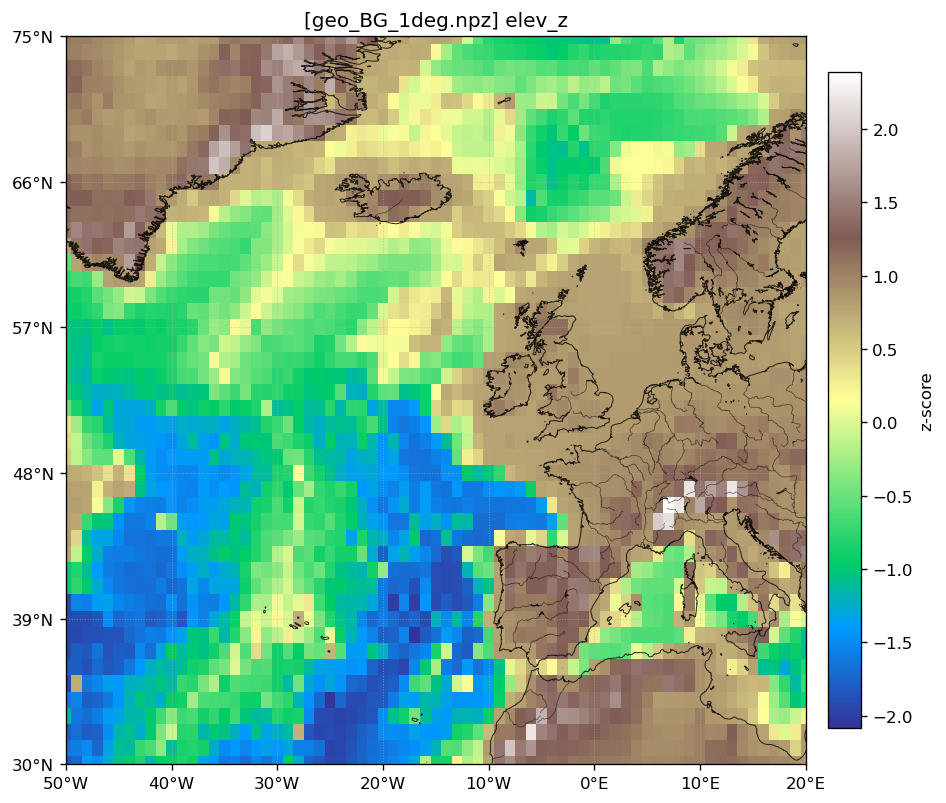

In [15]:
plot_geo_npz(paths["BG"],  "elev_z",   oceans=oceans, lakes=lakes, rivers=rivers)

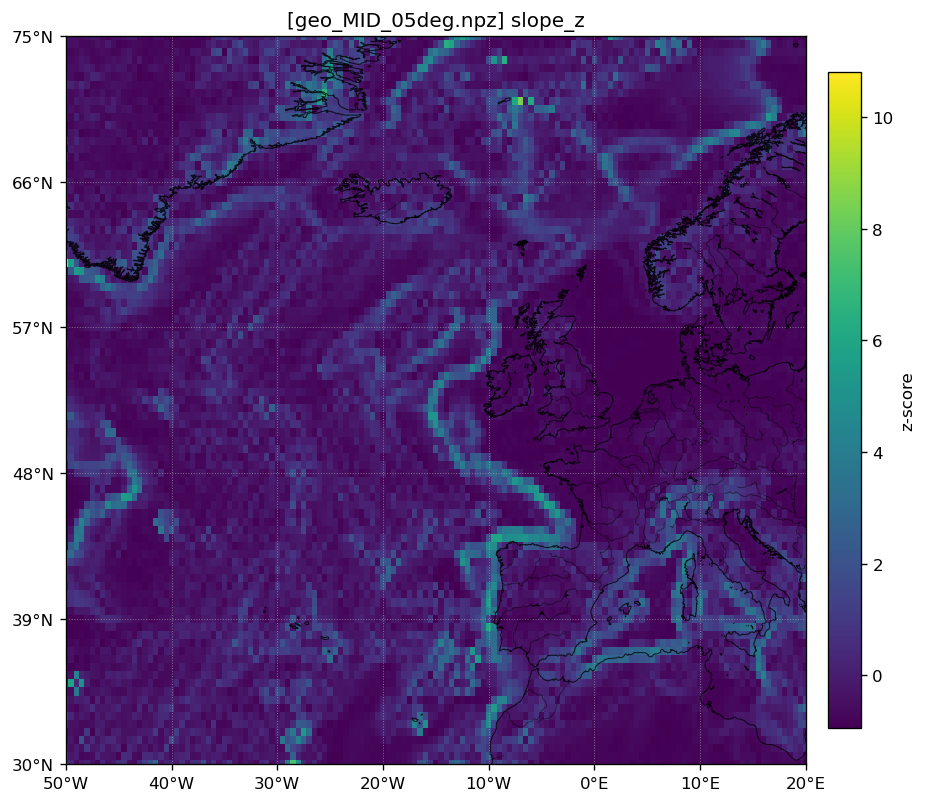

In [16]:
plot_geo_npz(paths["MID"], "slope_z",  oceans=oceans, lakes=lakes, rivers=rivers)

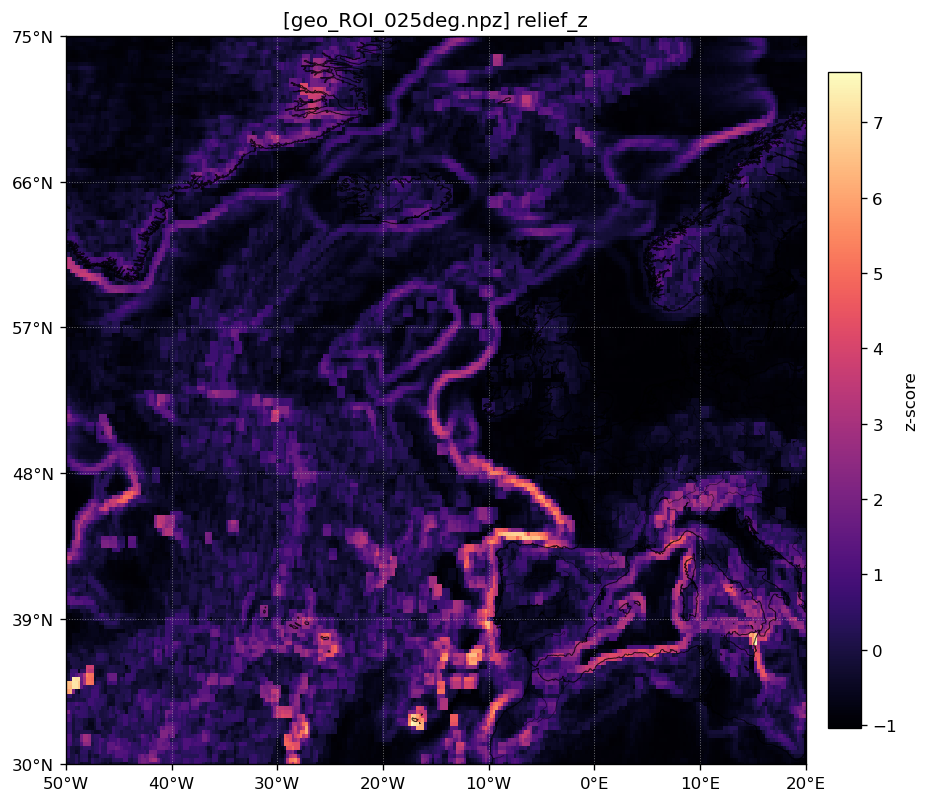

In [17]:
plot_geo_npz(paths["ROI"], "relief_z", oceans=oceans, lakes=lakes, rivers=rivers)

[geo_ROI_025deg.npz] water=1: 37002 / 50861 (72.75%), min=0.000, max=1.000


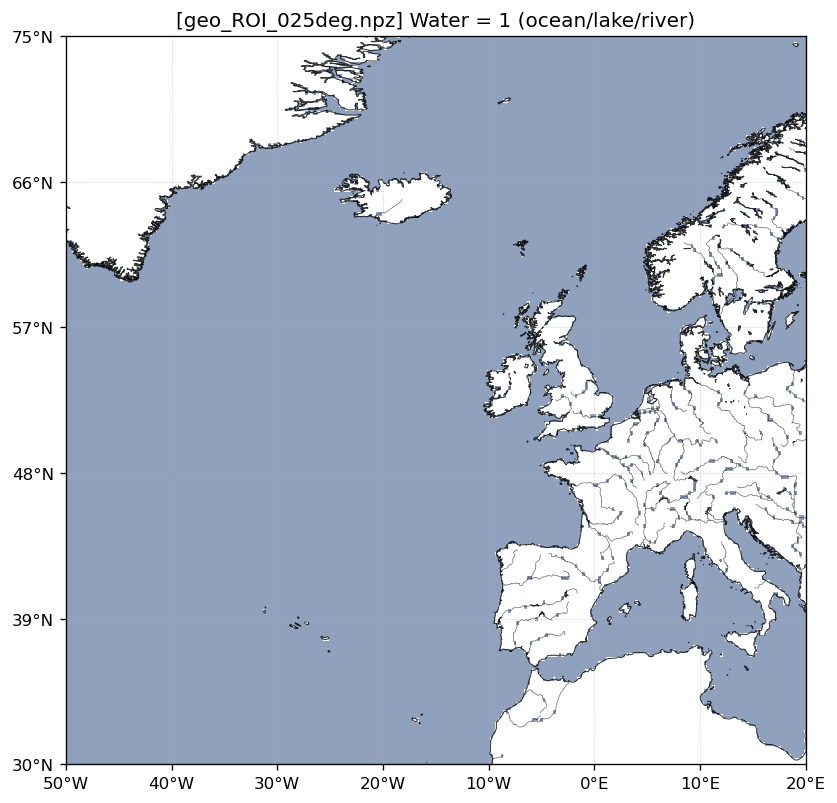

In [24]:
plot_geo_npz(paths["ROI"], "water_bin", oceans=oceans, lakes=lakes, rivers=rivers)

C:\Users\andri\AppData\Local\Temp\ipykernel_7500\1603787892.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


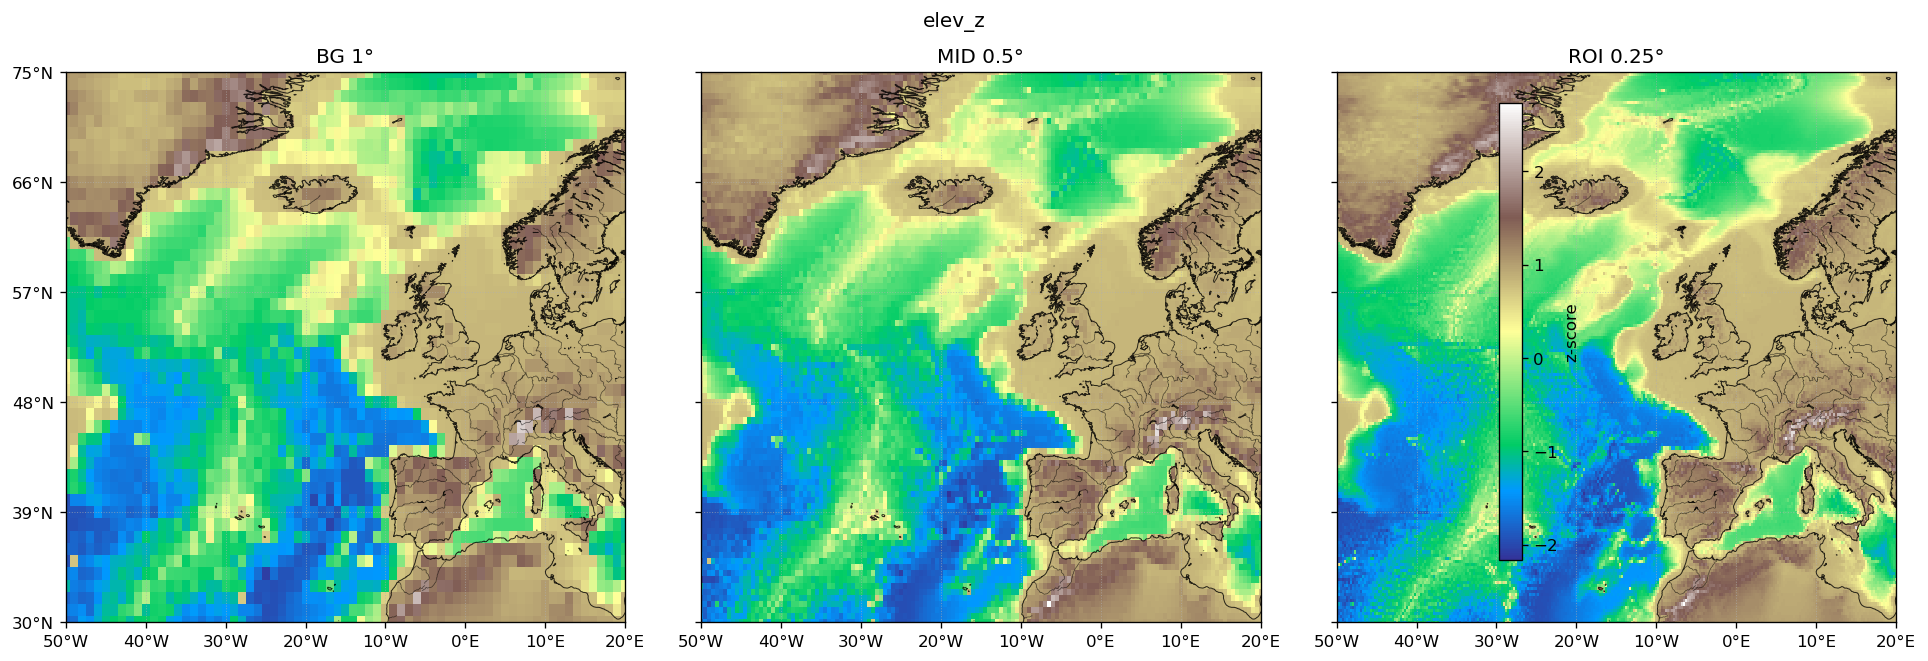

In [30]:
compare_levels(paths, "elev_z",   oceans=oceans, lakes=lakes, rivers=rivers)

C:\Users\andri\AppData\Local\Temp\ipykernel_7500\1603787892.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


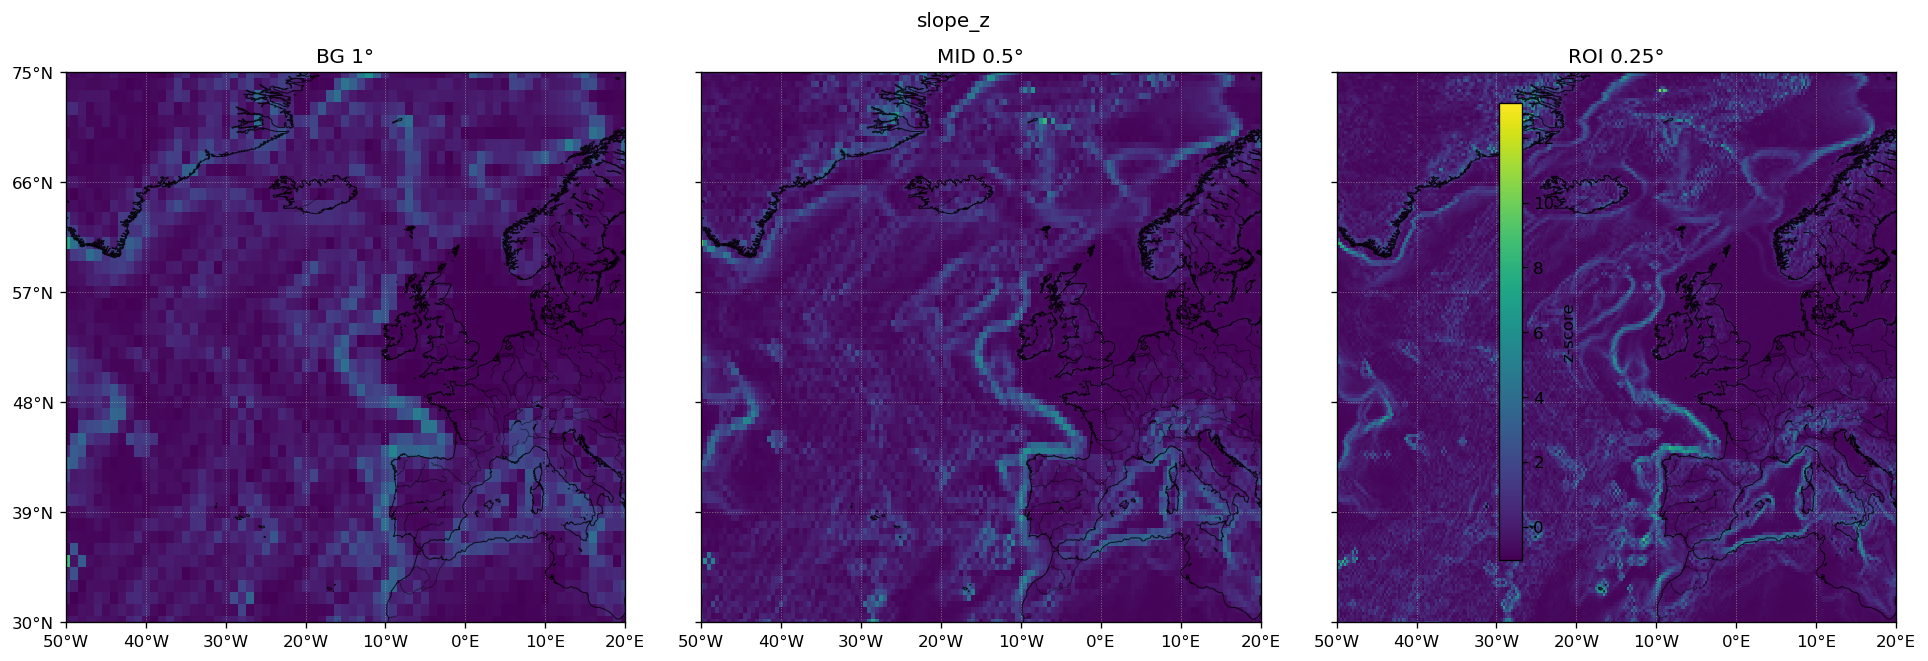

In [29]:
compare_levels(paths, "slope_z",  oceans=oceans, lakes=lakes, rivers=rivers)

C:\Users\andri\AppData\Local\Temp\ipykernel_7500\1603787892.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


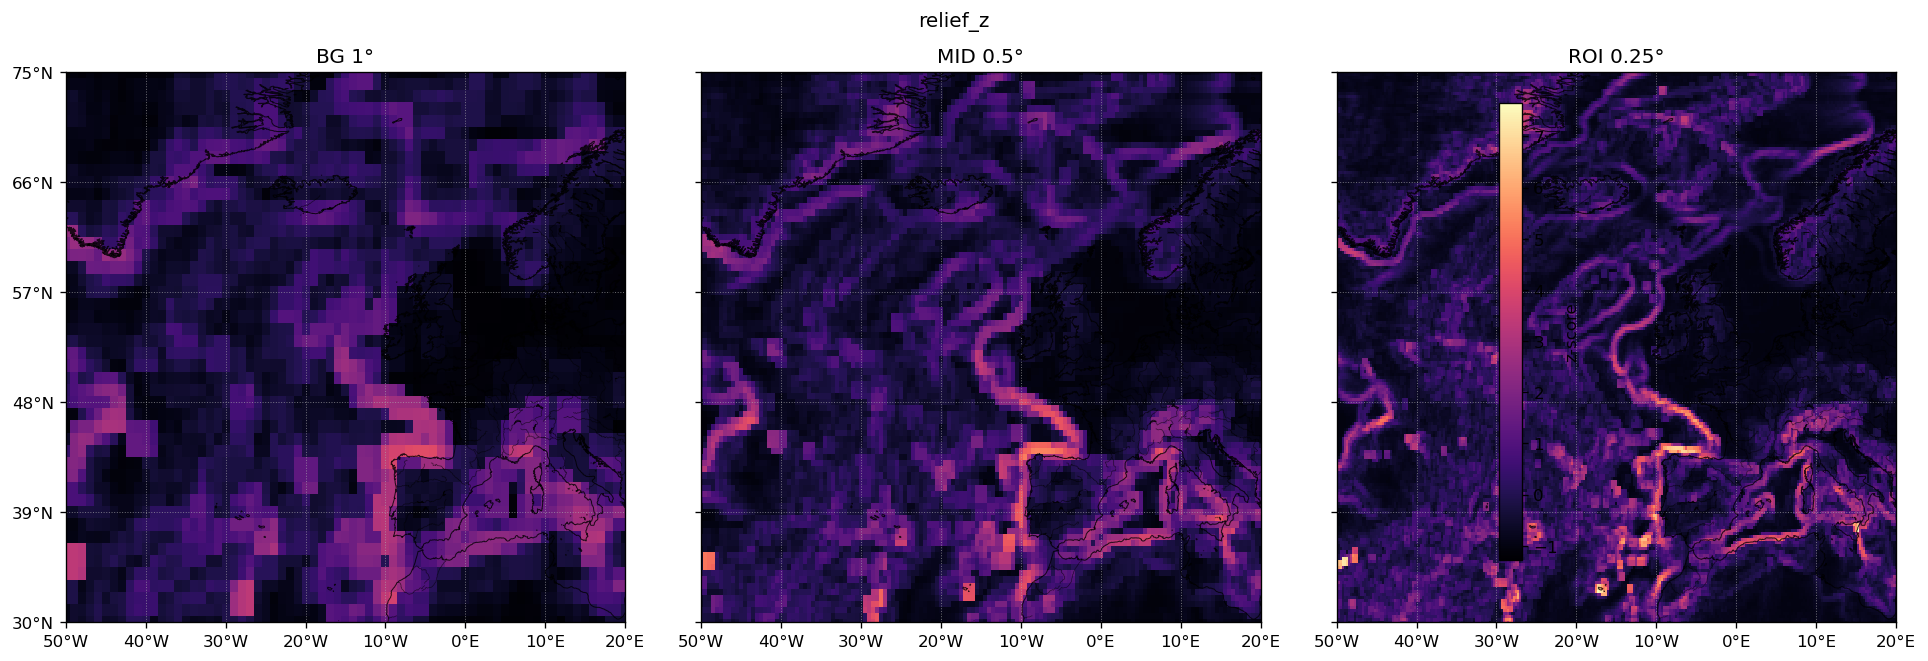

In [28]:
compare_levels(paths, "relief_z", oceans=oceans, lakes=lakes, rivers=rivers)

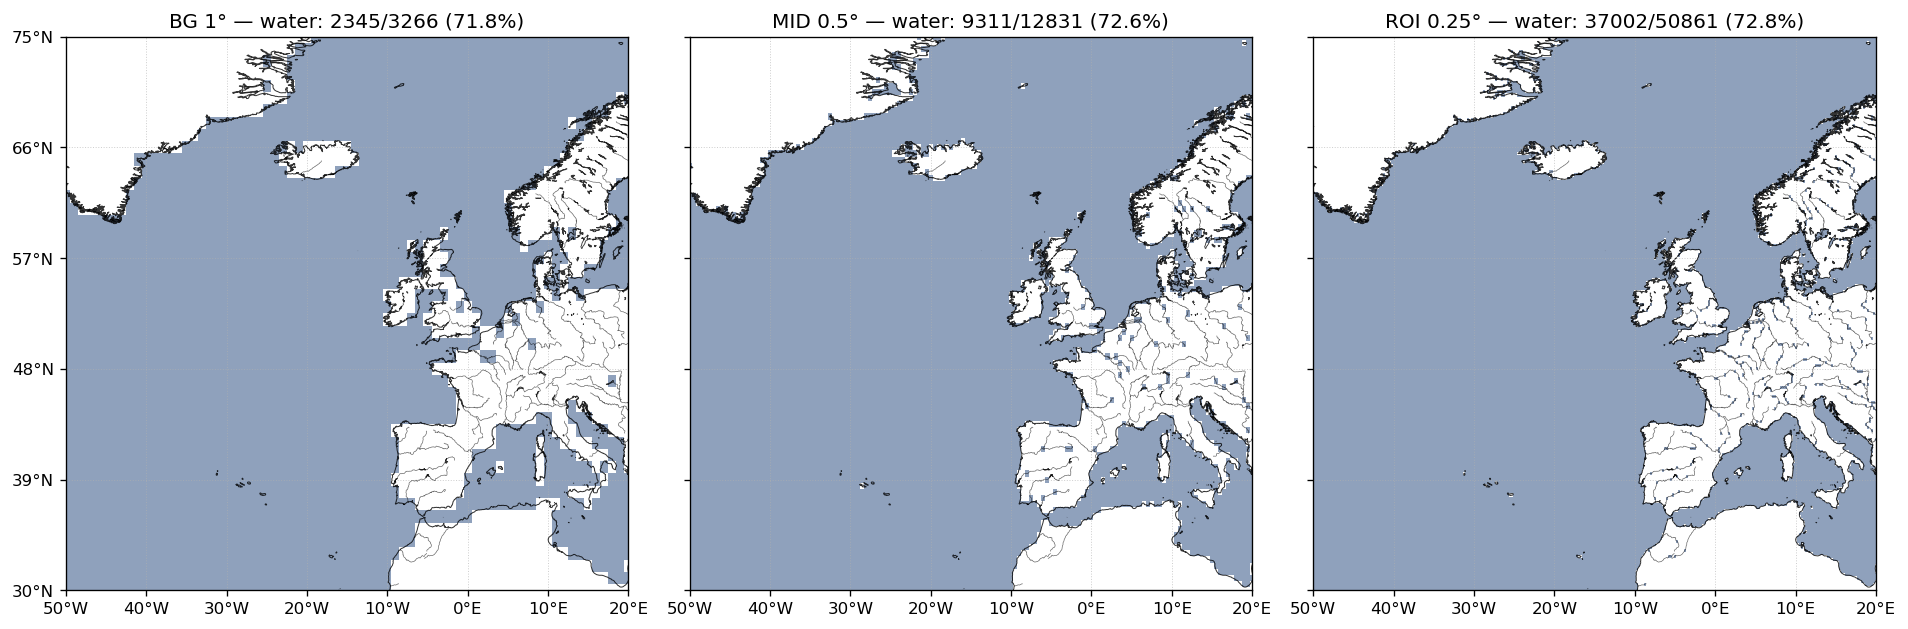

In [27]:
compare_levels(paths, "water_bin", oceans=oceans, lakes=lakes, rivers=rivers)